In [1]:
pip install cfgrib

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install --upgrade xarray 

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install geopandas shapely matplotlib cartopy 


   ---------------------------------------- 0.0/323.6 kB ? eta -:--:--
   - -------------------------------------- 10.2/323.6 kB ? eta -:--:--
   - -------------------------------------- 10.2/323.6 kB ? eta -:--:--
   - -------------------------------------- 10.2/323.6 kB ? eta -:--:--
   - -------------------------------------- 10.2/323.6 kB ? eta -:--:--
   --- ----------------------------------- 30.7/323.6 kB 145.2 kB/s eta 0:00:03
   --- ----------------------------------- 30.7/323.6 kB 145.2 kB/s eta 0:00:03
   ------- ------------------------------- 61.4/323.6 kB 204.8 kB/s eta 0:00:02
   ------- ------------------------------- 61.4/323.6 kB 204.8 kB/s eta 0:00:02
   -------- ------------------------------ 71.7/323.6 kB 206.9 kB/s eta 0:00:02
   ------------ ------------------------- 102.4/323.6 kB 256.0 kB/s eta 0:00:01
   ---------------- --------------------- 143.4/323.6 kB 327.1 kB/s eta 0:00:01
   ------------------------ ------------- 204.8/323.6 kB 444.2 kB/s eta 0:00:01
 

In [8]:
pip install h5netcdf

   ---------------------------------------- 0.0/50.1 kB ? eta -:--:--
   -------- ------------------------------- 10.2/50.1 kB ? eta -:--:--
   -------- ------------------------------- 10.2/50.1 kB ? eta -:--:--
   ------------------------ --------------- 30.7/50.1 kB 262.6 kB/s eta 0:00:01
   -------------------------------- ------- 41.0/50.1 kB 217.9 kB/s eta 0:00:01
   ---------------------------------------- 50.1/50.1 kB 255.3 kB/s eta 0:00:00
   ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
    --------------------------------------- 0.0/3.0 MB 393.8 kB/s eta 0:00:08
    --------------------------------------- 0.1/3.0 MB 660.6 kB/s eta 0:00:05
   - -------------------------------------- 0.1/3.0 MB 525.1 kB/s eta 0:00:06
   -- ------------------------------------- 0.2/3.0 MB 798.5 kB/s eta 0:00:04
   -- ------------------------------------- 0.2/3.0 MB 845.5 kB/s eta 0:00:04
   --- -------------

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.image as mpimg
from  matplotlib import cm
from pylab import *
import cartopy
import cartopy.crs as ccrs

from cartopy.feature import NaturalEarthFeature
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point

import cartopy.feature as cf
import cartopy.io.shapereader as shapereader
import glob
import xarray as xr
import netCDF4 as nc 

In [3]:
#import cfgrib

In [4]:
import h5netcdf

C:\Users\OWNER\anaconda3\envs\Dicks\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.3 when it was built against 1.14.2, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [5]:
import os
os.environ['CDSAPI_URL'] = 'https://ads.atmosphere.copernicus.eu/api'
os.environ['CDSAPI_KEY'] = '368d7647-81a1-4488-8726-a342447bca84'    

In [6]:
# Disable warnings for data download via API
import urllib3
urllib3.disable_warnings()

In [7]:
DATADIR = '/Users/OWNER/Desktop/Trapp/Python/Other Scripts/CAMS_air' #remove last directory

In [ ]:
import cdsapi

dataset = "cams-global-atmospheric-composition-forecasts"
request = {
    "variable": ["particulate_matter_2.5um"],
    "date": ["2026-02-28/2026-02-28/"], ##day of month is last on row
    "time": ["00:00"],
    "leadtime_hour": ["24"],
    "type": ["forecast"], 
    "data_format": "netcdf",
    "area": [12, -3.5, -4, 1.5] 
}

client = cdsapi.Client()
client.retrieve(dataset, request).download(f'{DATADIR}/fcst-28-Feb-26.nc') 

## 00 UTC forecast data availability guaranteed by 10:00 UTC
## 12 UTC forecast data availability guaranteed by 22:00 UTC
## It is possible that the data will be available earlier but without guarantee 

UPDATED API SYSTEM

In [457]:
import cdsapi # with updated CAMS information

dataset = "cams-global-atmospheric-composition-forecasts"
request = {
    "variable": ["particulate_matter_2.5um"],
    "date": ["2026-06-29/2026-06-29"],
    "time": ["00:00"],
    "leadtime_hour": ["24"],
    "type": ["forecast"],
    "data_format": "netcdf_zip",
    "area": [11.5, -3.5, 4, 1.5]  
}

client = cdsapi.Client() 
client.retrieve(dataset, request).download(f'{DATADIR}/fcst-29-Jun-26.nc') 


2026-06-30 08:51:16,639 WARNING [2026-06-25T00:00:00] Some data requests are currently failing due to an upstream data access issue. We have identified the cause and are working to restore normal service.
2026-06-30 08:51:16,647 INFO Request ID is ea0a0b7b-0a48-4c65-bae2-a1bcdfcb8fcb
2026-06-30 08:51:17,875 INFO status has been updated to accepted
2026-06-30 08:51:41,782 INFO status has been updated to running
2026-06-30 08:51:54,314 INFO status has been updated to successful


'/Users/OWNER/Desktop/Trapp/Python/Other Scripts/CAMS_air/fcst-29-Jun-26.nc'

In [458]:
import zipfile
import shutil

zip_path = "fcst-29-Jun-26.nc"
extract_path = "fcst_29-Jun_26_extracted" 

# Create extraction folder if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Extract
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Get extracted filename
extracted_files = os.listdir(extract_path)
print("Extracted files:", extracted_files)

# Assume only one file inside
original_file = os.path.join(extract_path, extracted_files[0])

# Define new clean filename
new_filename = os.path.join(extract_path, "fcst_29-Jun_26_processed.nc")

# Rename the file
shutil.move(original_file, new_filename) 

print("Renamed file saved as:", new_filename) 

Extracted files: ['data_sfc.nc']
Renamed file saved as: fcst_29-Jun_26_extracted\fcst_29-Jun_26_processed.nc


In [195]:
ds = xr.open_dataset('/Users/OWNER/Desktop/Trapp/Python/Other Scripts/CAMS_air/fcst_08-Jun_26_extracted/fcst_08-Jun_26_processed.nc') 
ds 

<xarray.Dataset> Size: 1kB
Dimensions:                  (forecast_period: 1, forecast_reference_time: 1,
                              latitude: 19, longitude: 12)
Coordinates:
  * forecast_period          (forecast_period) timedelta64[ns] 8B 1 days
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 8B 2026...
  * latitude                 (latitude) float64 152B 11.2 10.8 10.4 ... 4.4 4.0
  * longitude                (longitude) float64 96B -3.2 -2.8 -2.4 ... 0.8 1.2
    valid_time               (forecast_reference_time, forecast_period) datetime64[ns] 8B ...
Data variables:
    pm2p5                    (forecast_period, forecast_reference_time, latitude, longitude) float32 912B ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-10T12:32 GRIB to CDM+CF via cfgrib-0.9.1...

In [459]:
ds = xr.open_dataset("/Users/OWNER/Desktop/Trapp/Python/Other Scripts/CAMS_air/fcst_29-Jun_26_extracted/fcst_29-Jun_26_processed.nc")

variable_name = "pm2p5"  # ensure this matches your variable name in the NetCDF

#Convert values from kg to µg
ds[variable_name] = ds[variable_name] * 1e9

# Update units attribute
if "units" in ds[variable_name].attrs:
    old_units = ds[variable_name].attrs["units"]
    print(f"Changing units from {old_units} to µg/m³")
ds[variable_name].attrs["units"] = "µg/m³" 

# Save to new file 
output_file = "fcst-29-Jun_26_converted.nc"   
ds.to_netcdf(output_file)    

print(f"File saved as {output_file}")  

File saved as fcst-29-Jun_26_converted.nc


In [460]:
def netcdf_to_csv(netcdf_path, csv_path):
    try:
        # Attempt to open the NetCDF file
        dataset = xr.open_dataset('/Users/OWNER/Desktop/Trapp/Python/Other Scripts/CAMS_air/fcst-29-Jun_26_converted.nc', engine='h5netcdf')
    except FileNotFoundError:
        print(f"Error: The file '{netcdf_path}' does not exist.")
        return
    except Exception as e:
        print(f"Failed to open dataset: {e}")
        return
    
    # Convert the dataset to a pandas DataFrame
    df = dataset.to_dataframe().reset_index()
    
    # Save the DataFrame to CSV
    df.to_csv(csv_path, index=False)  
    print(f"Data saved to {csv_path}")  

# Call the function with your file paths 
netcdf_to_csv('/Users/OWNER/Desktop/Trapp/Python/Other Scripts/CAMS_air/fcst-29-Jun_26_converted.nc', '/Users/OWNER/Desktop/Trapp/Python/Other Scripts/CAMS_air/fcst-29-Jun_26_converted.csv')

Data saved to /Users/OWNER/Desktop/Trapp/Python/Other Scripts/CAMS_air/fcst-29-Jun_26_converted.csv


In [462]:
path= '/Users/OWNER/Desktop/Trapp/Python/Other Scripts/CAMS_air/fcst-29-Jun_26_converted.nc'
fig_path= '/Users/OWNER/Desktop/Trapp/Python/Other Scripts/gh_shapefile/' 

In [463]:
df1=xr.open_dataset('/Users/OWNER/Desktop/Trapp/Python/Other Scripts/CAMS_air/fcst-29-Jun_26_converted.nc') 

In [464]:
df1

<xarray.Dataset> Size: 1kB
Dimensions:                  (forecast_period: 1, forecast_reference_time: 1,
                              latitude: 19, longitude: 12)
Coordinates:
  * forecast_period          (forecast_period) timedelta64[ns] 8B 1 days
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 8B 2026...
  * latitude                 (latitude) float64 152B 11.2 10.8 10.4 ... 4.4 4.0
  * longitude                (longitude) float64 96B -3.2 -2.8 -2.4 ... 0.8 1.2
    valid_time               (forecast_reference_time, forecast_period) datetime64[ns] 8B ...
Data variables:
    pm2p5                    (forecast_period, forecast_reference_time, latitude, longitude) float32 912B ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-30T08:51 GRIB to CDM+CF via cfgrib-0.9.1...

In [465]:
# INDICATE THE NC FILES TO BE PLOTTED
# can't be more than 6 files
dfiles=[df1]
titles=["CAMS Air Quality Forecast"] 

In [466]:
vrble=[]
for l in dfiles:
    vrble.append(list(l.keys())[0])

##MODIFIED CODE FOR CUSTOM COLORMAP##

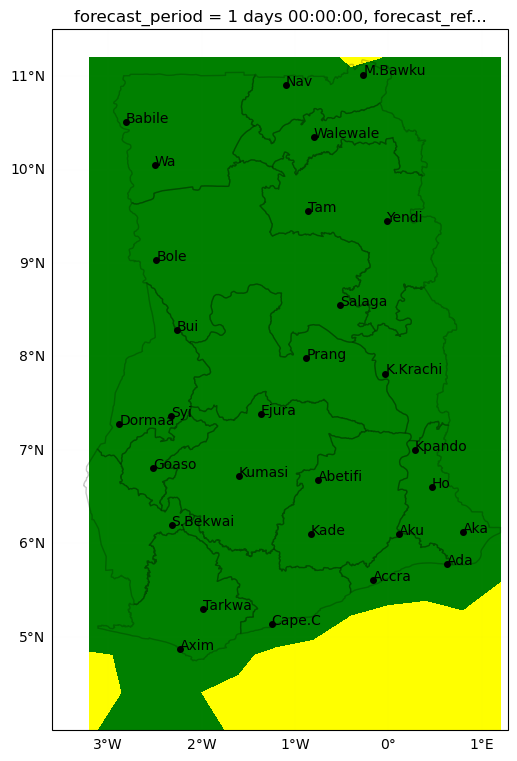

In [467]:
##NOW THIS IS WORKING
import matplotlib.colors as mcolors

# custom colormap and levels
cmap = mcolors.ListedColormap(["green", "yellow", "orange", "red", "purple","darkred"])
bounds = [0, 12.0, 35.4, 55.4, 150.4, 250.4, 500]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Create figure and axes
plt.figure(figsize=(20, 80))
for n in range(1, 2):
    ax = plt.subplot(3, 3, n, projection=ccrs.PlateCarree())

shp_path = '/Users/OWNER/Desktop/Trapp/Python/Other Scripts/gh_shapefile/gha_admbnda_adm1_gss_20210308.shp'
adm1_shapes = list(shapereader.Reader(str(shp_path)).geometries())
ax.add_geometries(adm1_shapes, ccrs.PlateCarree(), edgecolor="black", facecolor="none", alpha=0.2)

n = 0
for tem in range(len(dfiles)):
    v = vrble[tem]
    n += 1
    ax = plt.subplot(3, 3, n, projection=ccrs.PlateCarree())
    adm1_shapes = list(shapereader.Reader(str(shp_path)).geometries()) 
    
    # Process data to ensure it's 2D - IMPROVED VERSION
    data = dfiles[tem][vrble[tem]]
    
    # Enhanced 2D conversion with error handling
    if len(data.dims) == 2:
        data_2d = data  # Already 2D
    elif "time" in data.dims:
        data_2d = data.isel(time=0)  # Select first timestep
    elif len(data.dims) > 2:
        # Handle extra dimensions by selecting first element
        extra_dims = [dim for dim in data.dims if dim not in ['lat', 'lon', 'latitude', 'longitude']]
        if extra_dims:
            data_2d = data.isel(**{dim: 0 for dim in extra_dims})
        else:
            data_2d = data
    else:
        data_2d = data  # Fallback

    # Plot the data
    r = data_2d.plot.contourf(
        cmap=cmap,
        norm=norm,
        transform=ccrs.PlateCarree(),
        levels=bounds,
        add_colorbar=False
    )

    ax.add_geometries(adm1_shapes, ccrs.PlateCarree(), edgecolor="black", facecolor="none", alpha=0.02)
    gl = ax.gridlines(draw_labels=True, linewidth=0.01, color="gray")
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True
    ax.set_xlim(-3.6, 1.28)
    ax.set_ylim(4.0, 11.50)

    cities = [
    (-2.2333, 4.8667, 'Axim'),(-0.168, 5.6098, 'Accra'),(0.8, 6.12, 'Aka'),(0.1167, 6.1, 'Aku'),(-0.75, 6.68, 'Abetifi'),(-2.3211, 6.1965, 'S.Bekwai'),
    (-1.6, 6.72, 'Kumasi'),(0.4667, 6.6, 'Ho'),(-0.0333, 7.8167, 'K.Krachi'),(-2.4833, 9.0333, 'Bole'),(-0.02, 9.45, 'Yendi'),(-0.8624, 9.5539, 'Tam'),
    (-2.5, 10.05, 'Wa'),(-1.1, 10.9, 'Nav'),(-1.25, 5.13, 'Cape.C'),(0.63, 5.78, 'Ada'),(-2.81, 10.51, 'Babile'),(-2.266667, 8.283333, 'Bui'),(-2.88, 7.28, 'Dormaa'),(-1.3667, 7.3833, 'Ejura'),
    (-2.5167, 6.8, 'Goaso'),(-0.8333, 6.1, 'Kade'),(0.2833, 7, 'Kpando'),(-0.2667, 11.0167, 'M.Bawku'),(-0.88, 7.98, 'Prang'),(-0.5167, 8.55, 'Salaga'),
    (-1.98, 5.3, 'Tarkwa'),(-0.8, 10.35, 'Walewale'),(-2.3299, 7.3592, 'Syi') 
]
   
    for lon, lat, name in cities:
            ax.plot(lon, lat, color='black', marker='.', markersize=8, transform=ccrs.PlateCarree())
            ax.text(lon, lat, name, color='black', fontsize=10, transform=ccrs.PlateCarree())
        

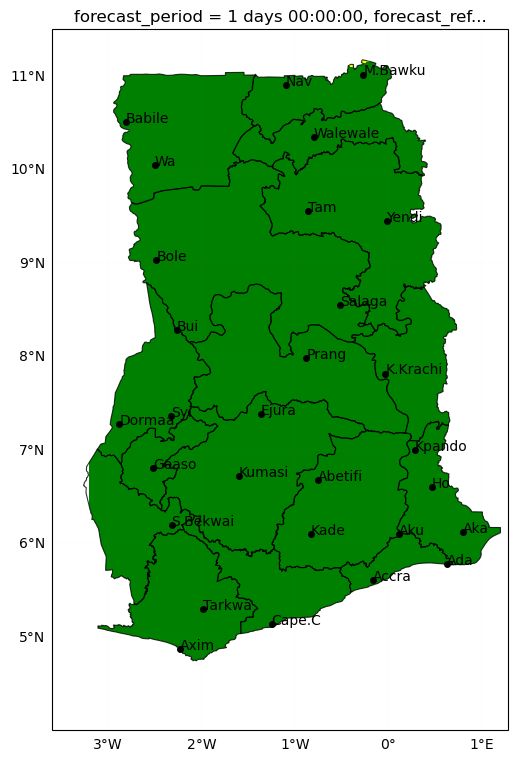

In [468]:
import matplotlib.colors as mcolors
from shapely.geometry import Polygon, MultiPolygon
import shapely.ops as ops

# Existing setup
cmap = mcolors.ListedColormap(["green", "yellow", "orange", "red", "purple", "darkred"])
bounds = [0, 12.0, 35.4, 55.4, 150.4, 250.4, 400]
#bounds = [0, 12, 35, 55, 150, 250, 400]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

#Figure and axes
plt.figure(figsize=(20, 80))

# Loading Ghana shapefile
shp_path = '/Users/OWNER/Desktop/Trapp/Python/Other Scripts/gh_shapefile/gha_admbnda_adm1_gss_20210308.shp'
reader = shapereader.Reader(str(shp_path))
records = list(reader.records())
ghana_geometries = [record.geometry for record in records]

# Calculate bounds from all geometries
all_bounds = [geom.bounds for geom in ghana_geometries]
minx = min(b[0] for b in all_bounds)
miny = min(b[1] for b in all_bounds)
maxx = max(b[2] for b in all_bounds)
maxy = max(b[3] for b in all_bounds)
ghana_bounds = (minx, miny, maxx, maxy)

# Combine all geometries into one for masking
combined_geometry = ops.unary_union(ghana_geometries)

n = 0
for tem in range(len(dfiles)):
    v = vrble[tem]
    n += 1
    ax = plt.subplot(3, 3, n, projection=ccrs.PlateCarree())
    
    # Process data to ensure it's 2D
    data = dfiles[tem][vrble[tem]]
    
    # Enhanced 2D conversion with error handling
    if len(data.dims) == 2:
        data_2d = data  # Already 2D
    elif "time" in data.dims:
        data_2d = data.isel(time=0)  # Select first timestep
    elif len(data.dims) > 2:
        extra_dims = [dim for dim in data.dims if dim not in ['lat', 'lon', 'latitude', 'longitude']]
        if extra_dims:
            data_2d = data.isel(**{dim: 0 for dim in extra_dims})
        else:
            data_2d = data
    else:
        data_2d = data

    # Plot the data first (full extent)
    r = data_2d.plot.contourf(
        cmap=cmap,
        norm=norm,
        transform=ccrs.PlateCarree(),
        levels=bounds,
        add_colorbar=False,
        extend='both'
    )

    # METHOD 1: Add white mask over areas outside Ghana
    # Create a world polygon and subtract Ghana from it
    world = Polygon([(-180, -90), (-180, 90), (180, 90), (180, -90)])
    outside_ghana = world.difference(combined_geometry)
    
    ax.add_geometries(
        [outside_ghana], 
        ccrs.PlateCarree(),
        facecolor='white', 
        edgecolor='none',
        alpha=1.0,
        zorder=2
    )
    
    # Add Ghana borders on top
    ax.add_geometries(
        ghana_geometries, 
        ccrs.PlateCarree(),
        facecolor='none', 
        edgecolor='black',
        linewidth=0.8,
        alpha=0.8,
        zorder=3
    )

    # Gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.01, color="gray")
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True
    ax.set_xlim(-3.6, 1.28)
    ax.set_ylim(4.0, 11.50)

    cities = [
        (-2.2333, 4.8667, 'Axim'), (-0.168, 5.6098, 'Accra'), (0.8, 6.12, 'Aka'), (0.1167, 6.1, 'Aku'), (-0.75, 6.68, 'Abetifi'), (-2.3211, 6.1965, 'S.Bekwai'),
        (-1.6, 6.72, 'Kumasi'), (0.4667, 6.6, 'Ho'), (-0.0333, 7.8167, 'K.Krachi'), (-2.4833, 9.0333, 'Bole'), (-0.02, 9.45, 'Yendi'), (-0.8624, 9.5539, 'Tam'),
        (-2.5, 10.05, 'Wa'), (-1.1, 10.9, 'Nav'), (-1.25, 5.13, 'Cape.C'), (0.63, 5.78, 'Ada'), (-2.81, 10.51, 'Babile'), (-2.266667, 8.283333, 'Bui'), 
        (-2.88, 7.28, 'Dormaa'), (-1.3667, 7.3833, 'Ejura'), (-2.5167, 6.8, 'Goaso'), (-0.8333, 6.1, 'Kade'), (0.2833, 7, 'Kpando'), (-0.2667, 11.0167, 'M.Bawku'), 
        (-0.88, 7.98, 'Prang'), (-0.5167, 8.55, 'Salaga'), (-1.98, 5.3, 'Tarkwa'), (-0.8, 10.35, 'Walewale'), (-2.3299, 7.3592, 'Syi')
    ]
   
    for lon, lat, name in cities:
        ax.plot(lon, lat, color='black', marker='.', markersize=8, 
                transform=ccrs.PlateCarree(), zorder=4)
        ax.text(lon, lat, name, color='black', fontsize=10, 
                transform=ccrs.PlateCarree(), zorder=4)

plt.savefig('PM2.5-fcst-30-Jun-26.jpg', dpi=300, bbox_inches='tight')
plt.show()   

##19-May-26 showed perfectly on viewer 

In [55]:
dc = xr.open_dataset('/Users/OWNER/Desktop/Trapp/Python/Other Scripts/CAMS_air/PM2.5-forecast-05-Dec-25_converted.nc')
dc

<xarray.Dataset> Size: 3kB
Dimensions:                  (forecast_period: 1, forecast_reference_time: 1,
                              latitude: 41, longitude: 13)
Coordinates:
  * forecast_period          (forecast_period) timedelta64[ns] 8B 1 days
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 8B 2025...
  * latitude                 (latitude) float64 328B 12.0 11.6 ... -3.6 -4.0
  * longitude                (longitude) float64 104B -3.5 -3.1 -2.7 ... 0.9 1.3
    valid_time               (forecast_reference_time, forecast_period) datetime64[ns] 8B ...
Data variables:
    pm2p5                    (forecast_period, forecast_reference_time, latitude, longitude) float32 2kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-12-11T09:28 GRIB to CDM+CF via cfgrib-0.9.1...

In [57]:
print(dc.data_vars)
  #dn =dc.drop

Data variables:
    pm2p5    (forecast_period, forecast_reference_time, latitude, longitude) float32 2kB ...


In [58]:
print(ds)

<xarray.Dataset> Size: 3kB
Dimensions:                  (forecast_period: 1, forecast_reference_time: 1,
                              latitude: 41, longitude: 13)
Coordinates:
  * forecast_period          (forecast_period) timedelta64[ns] 8B 1 days
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 8B 2026...
  * latitude                 (latitude) float64 328B 12.0 11.6 ... -3.6 -4.0
  * longitude                (longitude) float64 104B -3.5 -3.1 -2.7 ... 0.9 1.3
    valid_time               (forecast_reference_time, forecast_period) datetime64[ns] 8B ...
Data variables:
    pm2p5                    (forecast_period, forecast_reference_time, latitude, longitude) float32 2kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:       

In [59]:
print(ds.head())

<xarray.Dataset> Size: 204B
Dimensions:                  (forecast_period: 1, forecast_reference_time: 1,
                              latitude: 5, longitude: 5)
Coordinates:
  * forecast_period          (forecast_period) timedelta64[ns] 8B 1 days
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 8B 2026...
  * latitude                 (latitude) float64 40B 12.0 11.6 11.2 10.8 10.4
  * longitude                (longitude) float64 40B -3.5 -3.1 -2.7 -2.3 -1.9
    valid_time               (forecast_reference_time, forecast_period) datetime64[ns] 8B ...
Data variables:
    pm2p5                    (forecast_period, forecast_reference_time, latitude, longitude) float32 100B ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:          

In [ ]:
#/bin/bash#FRom Byll
####david codes for changing the netcdf file from grib to be compatible with the cms website
 
cdo chname,longitude,lon PM2.5-forecast-09-Dec-25_converted.nc tmp1.nc
cdo chname,latitude,lat tmp1.nc tmp2.nc
ncrename -d forecast_period,time -v forecast_period,time tmp2.nc
ncks -C -x -v forecast_reference_time tmp2.nc tmp3.nc
ncwa -a forecast_reference_time tmp3.nc tmp4.nc
ncks -C -x -v time tmp4.nc tmp5.nc
ncap2 -O -s time[time]=0 tmp5.nc tmp6.nc
ncatted -O -a units,time,o,c,"hours since 2025-12-09 00:00:00" -a standard_name,time,o,c,"time" -a calendar,time,o,c,"proleptic_gregorian" tmp6.nc

###regridding from 44km to 1km
cdo -O remapnn,grid_1km.txt tmp6.nc PM2.5-1km.nc
rm tmp*.nc

In [469]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="Engine .* loading failed",
    category=RuntimeWarning,
)

infile = "fcst-29-Jun_26_converted.nc"                      ##converted input_file
outfile_1km = "PM2.5_30-Jun-26-1km.nc"                                ##change to foecast valid date

ds = xr.open_dataset(infile, engine="netcdf4")

ds = ds.rename({"latitude": "lat", "longitude": "lon"}) 

ds = ds.rename_dims({"forecast_period": "time"})
ds = ds.rename_vars({"forecast_period": "time"})

ds = ds.isel(forecast_reference_time=0)

if "forecast_reference_time" in ds.variables:
    ds = ds.drop_vars("forecast_reference_time")
if "forecast_reference_time" in ds.dims:
    ds = ds.drop_dims("forecast_reference_time") 

if "valid_time" in ds.variables:
    ds = ds.drop_vars("valid_time") 

if "time" in ds.variables:  
    ds = ds.drop_vars("time") 

base_time = np.datetime64("2026-06-30T00:00:00")                           ##change to forecast valid date
ds["time"] = xr.DataArray([base_time], dims=("time",))
ds["time"].attrs = {
    "standard_name": "time", 
    "long_name": "time",  
}

# 8. Create 1 km target grid (974 x 974)
Nx_target = 533 
Ny_target = 1778 

lon_new = np.linspace(ds["lon"].min(), ds["lon"].max(), Nx_target) 
lat_new = np.linspace(ds["lat"].min(), ds["lat"].max(), Ny_target) 

# 9. Interpolate PM2.5 data to new grid
# xarray interp supports linear interpolation
ds_1km = ds.interp(lon=lon_new, lat=lat_new, method="linear") 

# 10. Assign CF-compliant attributes
ds_1km["time"].attrs = {"standard_name": "time", "long_name": "time"}
ds_1km["lat"].attrs = {"standard_name": "latitude", "long_name": "latitude", "units": "degrees_north"}
ds_1km["lon"].attrs = {"standard_name": "longitude", "long_name": "longitude", "units": "degrees_east"}
ds_1km["pm2p5"].attrs = {"units": "µg/m³"}

ds_1km.to_netcdf(outfile_1km) 
ds.close() 
ds_1km.close() 

print("1 km preprocessing and regridding complete:", outfile_1km)  

1 km preprocessing and regridding complete: PM2.5_30-Jun-26-1km.nc


C:\Users\OWNER\AppData\Local\Temp\ipykernel_19012\3833770763.py:33: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ds["time"] = xr.DataArray([base_time], dims=("time",))


BARCELONA DUST CENTRE FORECAST EXPLORATION

In [21]:
bd = xr.open_dataset('/Users/OWNER/Desktop/Trapp/Python/Other Scripts/CAMS_air/BDC_data/20260123_3H_MEDIAN.nc')   
bd 

<xarray.Dataset> Size: 5MB
Dimensions:     (time: 25, latitude: 130, longitude: 184)
Coordinates:
  * time        (time) datetime64[ns] 200B 2026-01-23 ... 2026-01-26
  * longitude   (longitude) float32 736B -26.75 -26.25 -25.75 ... 64.25 64.75
  * latitude    (latitude) float32 520B 0.25 0.75 1.25 ... 63.75 64.25 64.75
Data variables:
    OD550_DUST  (time, latitude, longitude) float32 2MB ...
    SCONC_DUST  (time, latitude, longitude) float32 2MB ...
Attributes:
    history:  Fri Jan 23 12:06:38 2026: ncap2 -O -v -s where(OD550_DUST < 0) ...
    NCO:      netCDF Operators version 4.8.1 (Homepage = http://nco.sf.net, C...

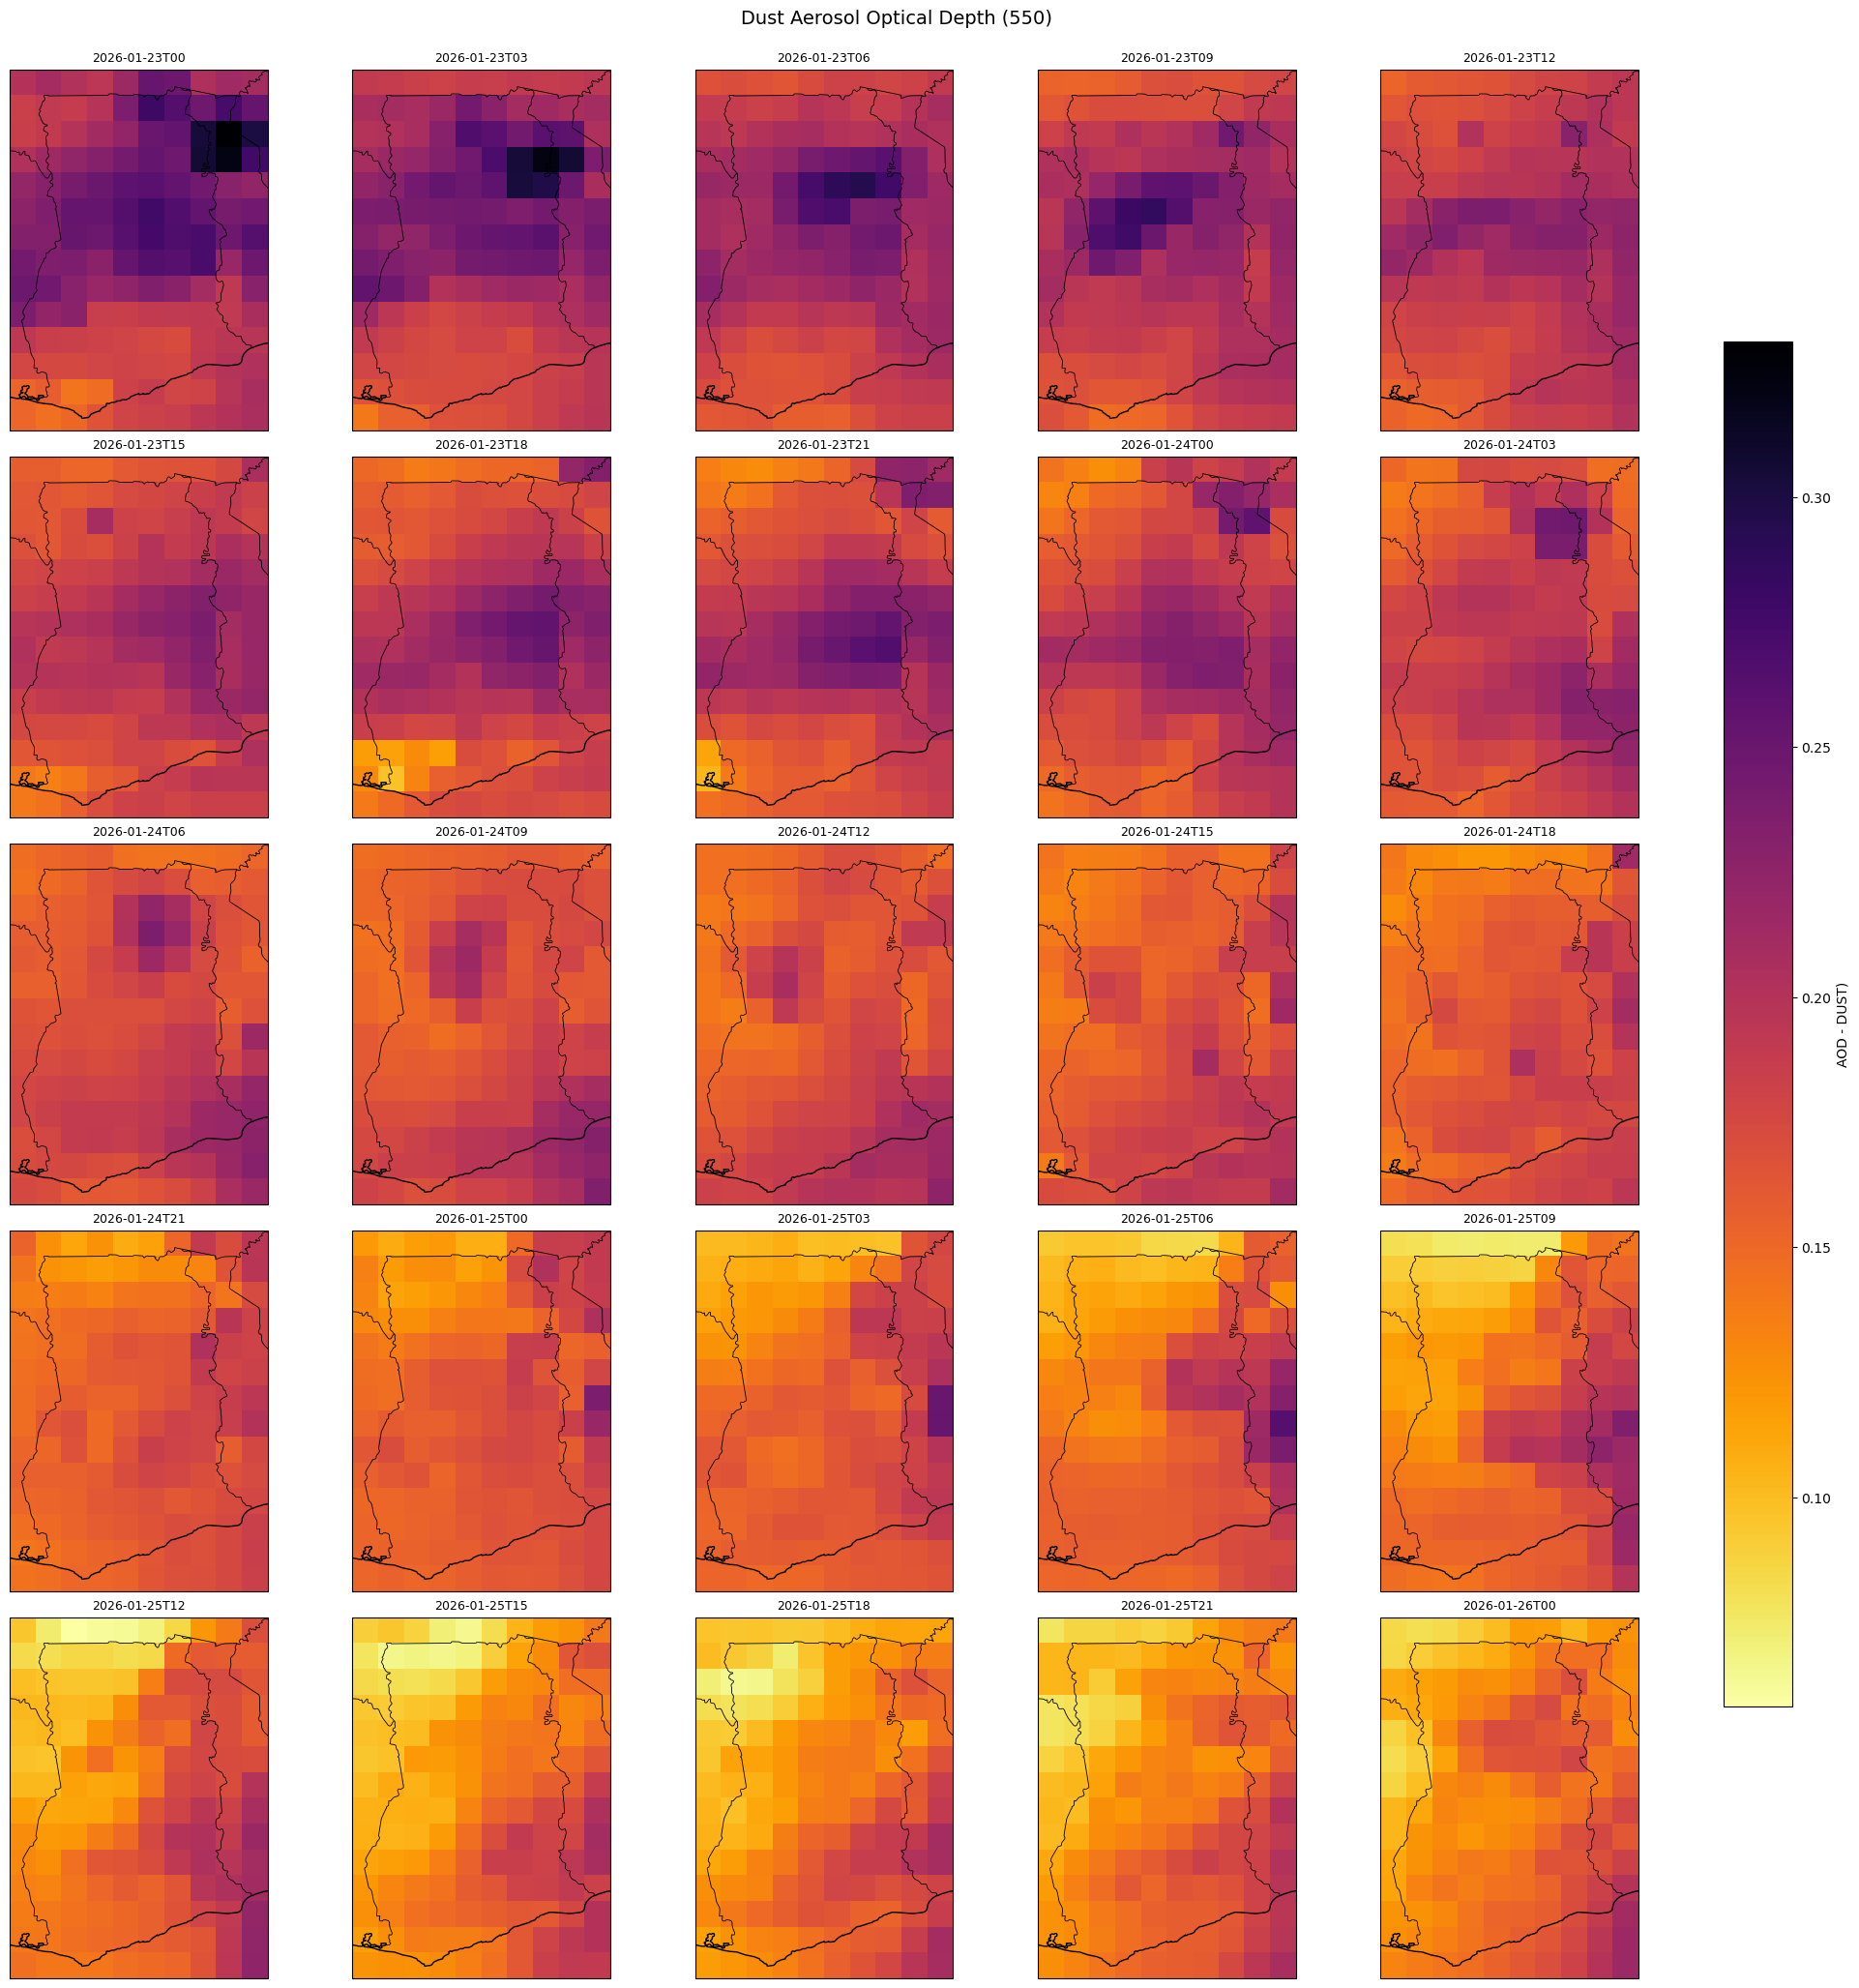

In [52]:
import math

# Load dataset
ds = xr.open_dataset(
    "/Users/OWNER/Desktop/Trapp/Python/Other Scripts/CAMS_air/BDC_data/20260123_3H_MEDIAN.nc",
    mask_and_scale=True
)

# Subset Ghana (handle latitude order)
if ds.latitude[0] < ds.latitude[-1]:
    ghana = ds.sel(latitude=slice(4.5, 11.5), longitude=slice(-3.5, 1.5))
else:
    ghana = ds.sel(latitude=slice(11.5, 4.5), longitude=slice(-3.5, 1.5))

# Extract variable
dust = ghana["OD550_DUST"].astype("float32")
dust = dust.where(np.isfinite(dust))

times = dust.time.values
nt = len(times)

# --- Subplot layout ---
ncols = 5
nrows = math.ceil(nt / ncols)

proj = ccrs.PlateCarree()

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(4*ncols, 4*nrows),
    subplot_kw={"projection": proj},
    constrained_layout=True
)

axes = axes.flatten()

# Fixed color scale (important for comparison)
vmin = float(dust.min())
vmax = float(dust.max())

for i, t in enumerate(times):
    ax = axes[i]
    da = dust.sel(time=t)

    im = ax.pcolormesh(
        da.longitude,
        da.latitude,
        da,
        cmap="inferno_r",
        vmin=vmin,
        vmax=vmax,
        transform=proj
    )

    ax.coastlines(resolution="10m")
    ax.add_feature(cfeature.BORDERS, linewidth=0.6)
    ax.set_extent([-3.5, 1.5, 4.5, 11.5])

    time_str = np.datetime_as_string(t, unit="h")
    ax.set_title(time_str, fontsize=9)

# Remove empty panels
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# --- Single shared colorbar ---
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="vertical",
    fraction=0.04,
    pad=0.05
)
cbar.set_label("AOD - DUST)")

fig.suptitle(
    "Dust Aerosol Optical Depth (550)",
    fontsize=14,
    y=1.02
)

plt.show()


In [53]:
!pip install imageio pillow


   ---------------------------------------- 0.0/317.6 kB ? eta -:--:--
   - -------------------------------------- 10.2/317.6 kB ? eta -:--:--
   - -------------------------------------- 10.2/317.6 kB ? eta -:--:--
   --- ----------------------------------- 30.7/317.6 kB 186.2 kB/s eta 0:00:02
   --- ----------------------------------- 30.7/317.6 kB 186.2 kB/s eta 0:00:02
   ----- --------------------------------- 41.0/317.6 kB 150.6 kB/s eta 0:00:02
   ------- ------------------------------- 61.4/317.6 kB 204.8 kB/s eta 0:00:02
   ------- ------------------------------- 61.4/317.6 kB 204.8 kB/s eta 0:00:02
   ------- ------------------------------- 61.4/317.6 kB 204.8 kB/s eta 0:00:02
   -------- ------------------------------ 71.7/317.6 kB 157.1 kB/s eta 0:00:02
   -------- ------------------------------ 71.7/317.6 kB 157.1 kB/s eta 0:00:02
   -------- ------------------------------ 71.7/317.6 kB 157.1 kB/s eta 0:00:02
   -------- ------------------------------ 71.7/317.6 kB 157.1 kB

In [54]:
import imageio
import os

ds = xr.open_dataset(
    "/Users/OWNER/Desktop/Trapp/Python/Other Scripts/CAMS_air/BDC_data/20260123_3H_MEDIAN.nc",
    mask_and_scale=True
)

# Subset Ghana (handle latitude order)
if ds.latitude[0] < ds.latitude[-1]:
    ghana = ds.sel(latitude=slice(4.5, 11.5), longitude=slice(-3.5, 1.5))
else:
    ghana = ds.sel(latitude=slice(11.5, 4.5), longitude=slice(-3.5, 1.5))

# Select variable
dust = ghana["OD550_DUST"].astype("float32")
dust = dust.where(np.isfinite(dust))

times = dust.time.values

out_dir = "/Users/OWNER/Desktop/Trapp/Python/Other Scripts/CAMS_air/BDC_data/gif_frames"
gif_path = "/Users/OWNER/Desktop/Trapp/Python/Other Scripts/CAMS_air/BDC_data/Ghana_Dust_AOD.gif"

os.makedirs(out_dir, exist_ok=True)

vmin = float(dust.min())
vmax = float(dust.max())

proj = ccrs.PlateCarree()
frames = []

# -----------------------------
# Create frames
# -----------------------------
for t in times:

    da = dust.sel(time=t)

    if da.count() == 0:
        continue

    fig = plt.figure(figsize=(6, 6))
    ax = plt.axes(projection=proj)

    im = ax.pcolormesh(
        da.longitude,
        da.latitude,
        da,
        cmap="inferno_r",
        vmin=vmin,
        vmax=vmax,
        transform=proj
    )

    ax.coastlines(resolution="10m")
    ax.add_feature(cfeature.BORDERS, linewidth=0.7)
    ax.set_extent([-3.5, 1.5, 4.5, 11.5])

    time_str = np.datetime_as_string(t, unit="h")
    ax.set_title(f"Dust AOD over Ghana\n{time_str} UTC")

    cbar = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.05)
    cbar.set_label("Aerosol Optical Depth")

    frame_path = f"{out_dir}/frame_{time_str.replace(':','')}.png"
    plt.savefig(frame_path, dpi=200, bbox_inches="tight")
    plt.close()

    frames.append(imageio.v2.imread(frame_path))

# -----------------------------
# Build GIF
# -----------------------------
imageio.mimsave(gif_path, frames, duration=0.8)

print(f"GIF animation saved to:\n{gif_path}")


GIF animation saved to:
/Users/OWNER/Desktop/Trapp/Python/Other Scripts/CAMS_air/BDC_data/Ghana_Dust_AOD.gif


C:\Users\OWNER\AppData\Local\Temp\ipykernel_20832\1062844613.py:150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.95])


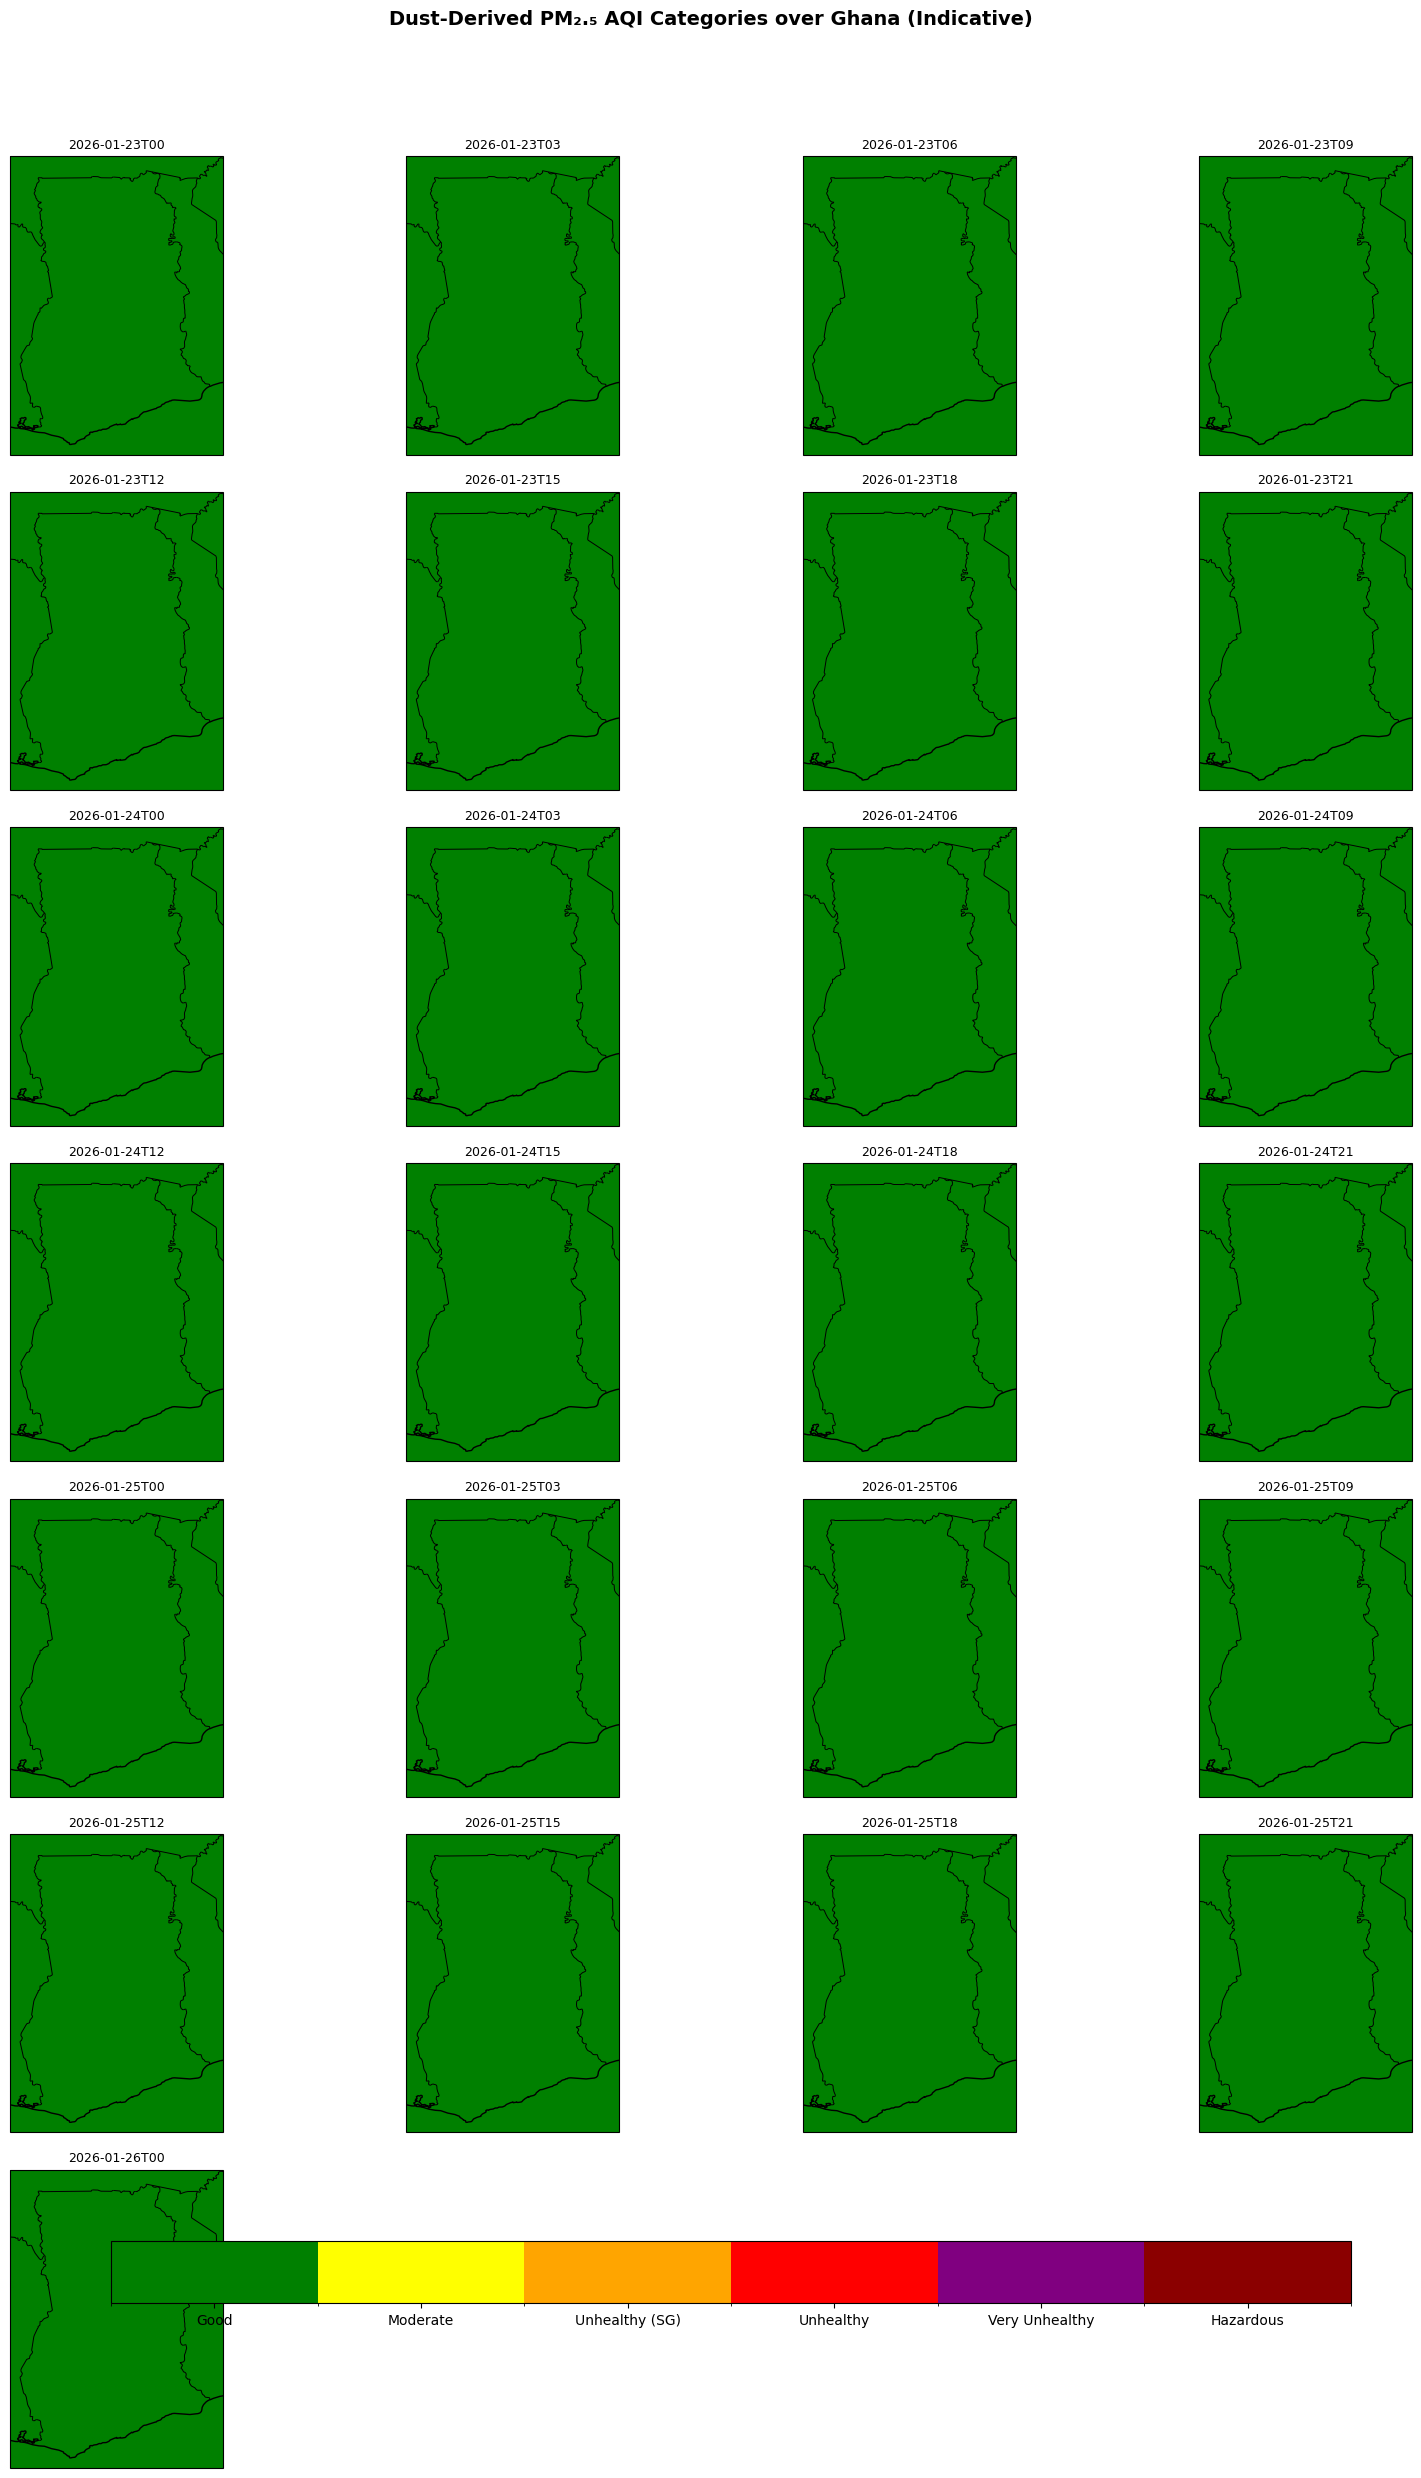

In [83]:
# Dust AOD → PM2.5 Proxy → AQI Category Maps over Ghana

import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

ds = xr.open_dataset(
    "/Users/OWNER/Desktop/Trapp/Python/Other Scripts/CAMS_air/BDC_data/20260123_3H_MEDIAN.nc",
    mask_and_scale=True
)

if ds.latitude[0] < ds.latitude[-1]:
    ghana = ds.sel(latitude=slice(4.5, 11.5), longitude=slice(-3.5, 1.5))
else:
    ghana = ds.sel(latitude=slice(11.5, 4.5), longitude=slice(-3.5, 1.5))

# ----------------------------------------------------------
# 3. Extract dust AOD and clean
# ----------------------------------------------------------
dust = ghana["OD550_DUST"].astype("float32")
dust = dust.where(np.isfinite(dust))

# ----------------------------------------------------------
# 4. Convert dust AOD → PM2.5 proxy
# ----------------------------------------------------------
DUST_AOD_TO_PM25 = 100.0  # µg/m³ per unit AOD (West Africa)

pm25_proxy = dust * DUST_AOD_TO_PM25
pm25_proxy.attrs.update({
    "long_name": "PM2.5 proxy from dust AOD",
    "units": "µg m-3",
    "description": (
        "Dust-derived PM2.5 proxy using scaling factor "
        "of 100 µg/m³ per unit AOD. Indicative only."
    )
})

# ----------------------------------------------------------
# 5. Convert PM2.5 → AQI category index
# ----------------------------------------------------------
def pm25_to_aqi_category(pm):
    return xr.where(pm <= 12, 0,
           xr.where(pm <= 35.4, 1,
           xr.where(pm <= 55.4, 2,
           xr.where(pm <= 150.4, 3,
           xr.where(pm <= 250.4, 4, 5))))) #12, 35.4, 55.4, 150.4, 250.4, 400 --was former AQI levels up to 300 

aqi_cat = pm25_to_aqi_category(pm25_proxy)
aqi_cat.attrs["long_name"] = "AQI category (dust-derived PM2.5 proxy)"

# ----------------------------------------------------------
# 6. AQI colormap and normalization
# ----------------------------------------------------------
aqi_colors = [
    "green",     # Good
    "yellow",    # Moderate
    "orange",    # Unhealthy (SG)
    "red",       # Unhealthy
    "purple",    # Very Unhealthy
    "darkred"    # Hazardous
]

cmap = mcolors.ListedColormap(aqi_colors)
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# ----------------------------------------------------------
# 7. Multi-panel AQI maps (ALL timesteps)
# ----------------------------------------------------------
times = aqi_cat.time.values
n = len(times)
ncols = 4
nrows = int(np.ceil(n / ncols))

proj = ccrs.PlateCarree()
fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(4 * ncols, 3.8 * nrows),
    subplot_kw={"projection": proj}
)

axes = axes.flatten()

for i, t in enumerate(times):
    ax = axes[i]
    da = aqi_cat.sel(time=t)

    im = ax.pcolormesh(
        da.longitude,
        da.latitude,
        da,
        cmap=cmap,
        norm=norm,
        transform=proj
    )

    ax.coastlines(resolution="10m")
    ax.add_feature(cfeature.BORDERS, linewidth=0.7)
    ax.set_extent([-3.5, 1.5, 4.5, 11.5])

    time_str = np.datetime_as_string(t, unit="h")
    ax.set_title(time_str, fontsize=9)

# Remove unused panels
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# ----------------------------------------------------------
# 8. Single shared AQI legend
# ----------------------------------------------------------
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="horizontal",
    fraction=0.04,
    pad=0.04,
    ticks=[0, 1, 2, 3, 4, 5]
)

cbar.ax.set_xticklabels([
    "Good",
    "Moderate",
    "Unhealthy (SG)",
    "Unhealthy",
    "Very Unhealthy",
    "Hazardous"
])

# ----------------------------------------------------------
# 9. Figure title and display
# ----------------------------------------------------------
fig.suptitle(
    "Dust-Derived PM₂.₅ AQI Categories over Ghana (Indicative)",
    fontsize=14,
    weight="bold"
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()
